# **Install pandas**

In [ ]:
# use the pip install command
pip install pandas

In [ ]:
# After installing pandas, it's good practice to check the installed version to ensure everything
# is working correctly:
import pandas as pd
print(pd.__version__)  # Prints the pandas version

2.2.2


# **Importing data in pandas**

In [ ]:
# import the pandas Python
# the most common alias for pandas is pd
import pandas as pd

**Importing CSV files**

In [ ]:
# Use read_csv() with the path to the CSV file
df = pd.read_csv("/content/diabetes.csv")

This read operation loads the CSV file diabetes.csv to generate a pandas Dataframe object df. Throughout this tutorial, you'll see how to manipulate such DataFrame objects.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

**Importing text files**

In [ ]:
df = pd.read_csv("/content/diabetes.txt", sep="\t")

Reading text files is similar to CSV files. The only nuance is that you need to specify a separator with the sep argument, as shown below. The separator argument refers to the symbol used to separate rows in a DataFrame. Comma (sep = ","), whitespace(sep = "\s"), tab (sep = "\t"), and colon(sep = ":") are the commonly used separators. Here \s represents a single white space character.

**Importing Excel files (single sheet)**

In [ ]:
df = pd.read_excel("/content/diabetes.xlsx")

**Importing Excel files (multiple sheets)**

In [ ]:
# Extracting the first sheet since Python uses 0-indexing
df = pd.read_excel("/content/diabetes_multi.xlsx", sheet_name=0)

Reading Excel files with multiple sheets is not that different. You just need to specify one additional argument, sheet_name, where you can either pass a string for the sheet name or an integer for the sheet position (note that Python uses 0-indexing, where the first sheet can be accessed with sheet_name = 0)

In [ ]:
df = pd.read_json("/content/diabetes.json")

**Importing data from SQL databases**

In [ ]:
import sqlite3

# Establish a connection to an SQLite database
conn = sqlite3.connect("my_database.db")

# Read data from a table
df = pd.read_sql("SELECT * FROM my_table", conn)

To load data from a relational database, use pd.read_sql() along with a database connection. For large datasets, consider using SQLAlchemy to optimize queries.

**Importing data from an API (JSON Format)**

In [ ]:
df = pd.read_json("https://api.example.com/data.json")

If your data is coming from a web API, pandas can read it directly using pd.read_json():

# **Outputting data in pandas**

Just as pandas can import data from various file types, it also allows you to export data into various formats. This happens especially when data is transformed using pandas and needs to be saved locally on your machine. Below is how to output pandas DataFrames into various formats.

**Outputting a DataFrame into a CSV file**

In [ ]:
df.to_csv("diabetes_out.csv", index=False)

A pandas DataFrame (here we are using df) is saved as a CSV file using the .to_csv() method. The arguments include the filename with path and index – where index = True implies writing the DataFrame’s index.

**Outputting a DataFrame into a JSON file**

In [ ]:
df.to_json("diabetes_out.json")

Export DataFrame object into a JSON file by calling the .to_json() method.

**Note:** A JSON file stores a tabular object like a DataFrame as a key-value pair. Thus you would observe repeating column headers in a JSON file.

**Outputting a DataFrame into a text file**

In [ ]:
df.to_csv('diabetes_out.txt', header=df.columns, index=None, sep=' ')

As with writing DataFrames to CSV files, you can call .to_csv(). The only differences are that the output file format is in .txt, and you need to specify a separator using the sep argument.

**Outputting a DataFrame into an Excel file**

In [ ]:
df.to_excel("diabetes_out.xlsx", index=False)

Call .to_excel() from the DataFrame object to save it as a “.xls” or “.xlsx” file.

# **Viewing and understanding DataFrames using pandas**

**View data using .head() and .tail()**

In [ ]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df.tail(n = 10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
758,1,106,76,0,0,37.5,0.197,26,0
759,6,190,92,0,0,35.5,0.278,66,1
760,2,88,58,26,16,28.4,0.766,22,0
761,9,170,74,31,0,44.0,0.403,43,1
762,9,89,62,0,0,22.5,0.142,33,0
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


**Understanding data using .describe()**

In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


The .describe() method prints the summary statistics of all numeric columns, such as count, mean, standard deviation, range, and quartiles of numeric columns. It gives a quick look at the scale, skew, and range of numeric data.

In [ ]:
df.describe(percentiles=[0.3, 0.5, 0.7])

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
30%,1.000000,102.000000,64.000000,8.200000,0.000000,28.200000,0.259000,25.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
70%,5.000000,134.000000,78.000000,31.000000,106.000000,35.490000,0.563700,38.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


You can also modify the quartiles using the percentiles argument. Here, for example, we’re looking at the 30%, 50%, and 70% percentiles of the numeric columns in DataFrame df.

You can also isolate specific data types in your summary output by using the include argument. Here, for example, we’re only summarizing the columns with the integer data type.


In [ ]:
df.describe(include=[int])

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,81.000000,1.000000


Similarly, you might want to exclude certain data types using exclude argument.

In [ ]:
df.describe(exclude=[int])

,BMI,DiabetesPedigreeFunction
count,768.000000,768.000000
mean,31.992578,0.471876
std,7.884160,0.331329
min,0.000000,0.078000
25%,27.300000,0.243750
50%,32.000000,0.372500
75%,36.600000,0.626250
max,67.100000,2.420000


Often, practitioners find it easy to view such statistics by transposing them with the .T attribute.

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


For more on describing DataFrames, check out the following [cheat sheet](https://www.datacamp.com/cheat-sheet/pandas-cheat-sheet-data-wrangling-in-python).

**Understanding data using .info()**

The .info() method is a quick way to look at the data types, missing values, and data size of a DataFrame. Here, we’re setting the show_counts argument to True, which gives a few over the total non-missing values in each column. We’re also setting memory_usage to True, which shows the total memory usage of the DataFrame elements. When verbose is set to True, it prints the full summary from .info().

In [ ]:
df.info(show_counts=True, memory_usage=True, verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


**Understanding your data using .shape**

In [ ]:
print(df.shape) # Get the number of rows and columns
print(df.shape[0]) # Get the number of rows only
print(df.shape[1]) # Get the number of columns only

(768, 9)
768
9


**Get all columns and column names**

Calling the .columns attribute of a DataFrame object returns the column names in the form of an Index object. As a reminder, a pandas index is the address/label of the row or column.

In [ ]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

It can be converted to a list using a list() function.

In [ ]:
list(df.columns)

['Pregnancies',
 'Glucose',
 'BloodPressure',
 'SkinThickness',
 'Insulin',
 'BMI',
 'DiabetesPedigreeFunction',
 'Age',
 'Outcome']

**Checking for missing values in pandas with .isnull()**

The sample DataFrame does not have any missing values. Let's introduce a few to make things interesting. The .copy() method makes a copy of the original DataFrame. This is done to ensure that any changes to the copy don’t reflect in the original DataFrame. Using .loc (to be discussed later), you can set rows two to five of the Pregnancies column to NaN values, which denote missing values.

In [ ]:
df2 = df.copy()
df2.loc[2:5,'Pregnancies'] = None
df2.head(7)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6.0,148,72,35,0,33.6,0.627,50,1
1,1.0,85,66,29,0,26.6,0.351,31,0
2,NaN,183,64,0,0,23.3,0.672,32,1
3,NaN,89,66,23,94,28.1,0.167,21,0
4,NaN,137,40,35,168,43.1,2.288,33,1
5,NaN,116,74,0,0,25.6,0.201,30,0
6,3.0,78,50,32,88,31.0,0.248,26,1


You can check whether each element in a DataFrame is missing using the .isnull() method.

In [ ]:
df2.isnull().head(7)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,True,False,False,False,False,False,False,False,False
3,True,False,False,False,False,False,False,False,False
4,True,False,False,False,False,False,False,False,False
5,True,False,False,False,False,False,False,False,False
6,False,False,False,False,False,False,False,False,False


Given it's often more useful to know how much missing data you have, you can combine .isnull() with .sum() to count the number of nulls in each column.

In [ ]:
df2.isnull().sum()

,0
Pregnancies,4
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


You can also do a double sum to get the total number of nulls in the DataFrame.

In [ ]:
df2.isnull().sum().sum()

np.int64(4)

# **Sorting, Slicing and Extracting Data in pandas**

**Sorting data**

To sort a DataFrame by a specific column:

In [ ]:
df.sort_values(by="Age", ascending=False, inplace=True)  # Sort by Age in descending order

You can sort by multiple columns:

In [ ]:
df.sort_values(by=["Age", "Glucose"], ascending=[True, True], inplace=True)

In [ ]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
182,1,0,74,20,23,27.7,0.299,21,0
273,1,71,78,50,45,33.2,0.422,21,0
55,1,73,50,10,0,23.0,0.248,21,0
290,0,78,88,29,40,36.9,0.434,21,0
90,1,80,55,0,0,19.1,0.258,21,0
...,...,...,...,...,...,...,...,...,...
123,5,132,80,0,0,26.8,0.186,69,0
684,5,136,82,0,0,0.0,0.640,69,0
666,4,145,82,18,0,32.5,0.235,70,1
453,2,119,0,0,0,19.6,0.832,72,0


**Resetting the index**

If you filter or sort a DataFrame, your index might become misaligned. Use .reset_index() to fix this:

In [ ]:
df.reset_index(drop=True, inplace=True)  # Resets index and removes old index column
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,1,0,74,20,23,27.7,0.299,21,0
1,1,71,78,50,45,33.2,0.422,21,0
2,1,73,50,10,0,23.0,0.248,21,0
3,0,78,88,29,40,36.9,0.434,21,0
4,1,80,55,0,0,19.1,0.258,21,0
...,...,...,...,...,...,...,...,...,...
763,5,132,80,0,0,26.8,0.186,69,0
764,5,136,82,0,0,0.0,0.640,69,0
765,4,145,82,18,0,32.5,0.235,70,1
766,2,119,0,0,0,19.6,0.832,72,0


**Filtering data using conditions**

In [ ]:
df[df["BloodPressure"] > 100]  # Selects rows where BloodPressure is greater than 100

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
291,0,129,110,46,130,67.1,0.319,26,1
307,1,96,122,0,0,22.4,0.207,27,0
525,5,137,108,0,0,48.8,0.227,37,1
532,4,189,110,31,0,28.5,0.680,37,0
593,0,189,104,25,0,34.3,0.435,41,1
624,8,167,106,46,231,37.6,0.165,43,1
634,13,158,114,0,0,42.3,0.257,44,1
644,1,133,102,28,140,32.8,0.234,45,1
663,10,68,106,23,49,35.5,0.285,47,0
688,11,127,106,0,0,39.0,0.190,51,0


**Isolating one column using [ ]**

You can isolate a single column using a square bracket [ ] with a column name in it. The output is a pandas Series object. A pandas Series is a one-dimensional array containing data of any type, including integer, float, string, boolean, python objects, etc. A DataFrame is comprised of many series that act as columns.

In [ ]:
df['Outcome']

,Outcome
0,0
1,0
2,0
3,0
4,0
...,...
763,0
764,0
765,1
766,0


**Isolating two or more columns using [[ ]]**

You can also provide a list of column names inside the square brackets to fetch more than one column. Here, square brackets are used in two different ways. We use the outer square brackets to indicate a subset of a DataFrame, and the inner square brackets to create a list.


In [ ]:
df[['Pregnancies', 'Outcome']]

,Pregnancies,Outcome
0,1,0
1,1,0
2,1,0
3,0,0
4,1,0
...,...,...
763,5,0
764,5,0
765,4,1
766,2,0


**Isolating one row using [ ]**

In [ ]:
df[df.index==1]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
1,1,71,78,50,45,33.2,0.422,21,0


**Isolating two or more rows using [ ]**

Similarly, two or more rows can be returned using the .isin() method instead of a == operator.

In [ ]:
df[df.index.isin(range(2,10))]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
2,1,73,50,10,0,23.0,0.248,21,0
3,0,78,88,29,40,36.9,0.434,21,0
4,1,80,55,0,0,19.1,0.258,21,0
5,2,84,50,23,76,30.4,0.968,21,0
6,2,84,0,0,0,0.0,0.304,21,0
7,0,84,64,22,66,35.8,0.545,21,0
8,3,87,60,18,0,21.8,0.444,21,0
9,1,89,24,19,25,27.8,0.559,21,0


**Using .loc[] and .iloc[] to fetch rows**

You can fetch specific rows by labels or conditions using .loc[] and .iloc[] ("location" and "integer location"). .loc[] uses a label to point to a row, column or cell, whereas .iloc[] uses the numeric position. To understand the difference between the two, let’s modify the index of df2 created earlier.

In [ ]:
df2.index = range(1,769)

In [ ]:
df2

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
1,6.0,148,72,35,0,33.6,0.627,50,1
2,1.0,85,66,29,0,26.6,0.351,31,0
3,NaN,183,64,0,0,23.3,0.672,32,1
4,NaN,89,66,23,94,28.1,0.167,21,0
5,NaN,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
764,10.0,101,76,48,180,32.9,0.171,63,0
765,2.0,122,70,27,0,36.8,0.340,27,0
766,5.0,121,72,23,112,26.2,0.245,30,0
767,1.0,126,60,0,0,30.1,0.349,47,1


The below example returns a pandas Series instead of a DataFrame. The 1 represents the row index (label), whereas the 1 in .iloc[] is the row position (first row).

In [ ]:
df2.loc[1]

,1
Pregnancies,6.000
Glucose,148.000
BloodPressure,72.000
SkinThickness,35.000
Insulin,0.000
BMI,33.600
DiabetesPedigreeFunction,0.627
Age,50.000
Outcome,1.000


In [ ]:
df2.iloc[1]

,2
Pregnancies,1.000
Glucose,85.000
BloodPressure,66.000
SkinThickness,29.000
Insulin,0.000
BMI,26.600
DiabetesPedigreeFunction,0.351
Age,31.000
Outcome,0.000


You can also fetch multiple rows by providing a range in square brackets.

In [ ]:
df2.loc[100:110]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
100,1.0,122,90,51,220,49.7,0.325,31,1
101,1.0,163,72,0,0,39.0,1.222,33,1
102,1.0,151,60,0,0,26.1,0.179,22,0
103,0.0,125,96,0,0,22.5,0.262,21,0
104,1.0,81,72,18,40,26.6,0.283,24,0
105,2.0,85,65,0,0,39.6,0.930,27,0
106,1.0,126,56,29,152,28.7,0.801,21,0
107,1.0,96,122,0,0,22.4,0.207,27,0
108,4.0,144,58,28,140,29.5,0.287,37,0
109,3.0,83,58,31,18,34.3,0.336,25,0


In [ ]:
df2.iloc[100:110]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
101,1.0,163,72,0,0,39.0,1.222,33,1
102,1.0,151,60,0,0,26.1,0.179,22,0
103,0.0,125,96,0,0,22.5,0.262,21,0
104,1.0,81,72,18,40,26.6,0.283,24,0
105,2.0,85,65,0,0,39.6,0.930,27,0
106,1.0,126,56,29,152,28.7,0.801,21,0
107,1.0,96,122,0,0,22.4,0.207,27,0
108,4.0,144,58,28,140,29.5,0.287,37,0
109,3.0,83,58,31,18,34.3,0.336,25,0
110,0.0,95,85,25,36,37.4,0.247,24,1


You can also subset with .loc[] and .iloc[] by using a list instead of a range.

In [ ]:
df2.loc[[100, 200, 300]]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
100,1.0,122,90,51,220,49.7,0.325,31,1
200,4.0,148,60,27,318,30.9,0.150,29,1
300,8.0,112,72,0,0,23.6,0.840,58,0


In [ ]:
df2.iloc[[100, 200, 300]]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
101,1.0,163,72,0,0,39.0,1.222,33,1
201,0.0,113,80,16,0,31.0,0.874,21,0
301,0.0,167,0,0,0,32.3,0.839,30,1


You can also select specific columns along with rows. This is where .iloc[] is different from .loc[] – it requires column location and not column labels.

In [ ]:
df2.loc[100:110, ['Pregnancies', 'Glucose', 'BloodPressure']]

,Pregnancies,Glucose,BloodPressure
100,1.0,122,90
101,1.0,163,72
102,1.0,151,60
103,0.0,125,96
104,1.0,81,72
105,2.0,85,65
106,1.0,126,56
107,1.0,96,122
108,4.0,144,58
109,3.0,83,58


In [ ]:
df2.iloc[100:110, :3]

,Pregnancies,Glucose,BloodPressure
101,1.0,163,72
102,1.0,151,60
103,0.0,125,96
104,1.0,81,72
105,2.0,85,65
106,1.0,126,56
107,1.0,96,122
108,4.0,144,58
109,3.0,83,58
110,0.0,95,85


For faster workflows, you can pass in the starting index of a row as a range.

In [ ]:
df2.loc[760:, ['Pregnancies', 'Glucose', 'BloodPressure']]

,Pregnancies,Glucose,BloodPressure
760,6.0,190,92
761,2.0,88,58
762,9.0,170,74
763,9.0,89,62
764,10.0,101,76
765,2.0,122,70
766,5.0,121,72
767,1.0,126,60
768,1.0,93,70


In [ ]:
df2.iloc[760:, :3]

,Pregnancies,Glucose,BloodPressure
761,2.0,88,58
762,9.0,170,74
763,9.0,89,62
764,10.0,101,76
765,2.0,122,70
766,5.0,121,72
767,1.0,126,60
768,1.0,93,70


**Conditional slicing (that fits certain conditions)**

pandas lets you filter data by conditions over row/column values. For example, the below code selects the row where Blood Pressure is exactly 122. Here, we are isolating rows using the brackets [ ] as seen in previous sections. However, instead of inputting row indices or column names, we are inputting a condition where the column BloodPressure is equal to 122. We denote this condition using df.BloodPressure == 122.

In [ ]:
df[df.BloodPressure == 122]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
307,1,96,122,0,0,22.4,0.207,27,0


In [ ]:
df[df.Outcome == 1]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
37,1,113,64,35,0,33.6,0.543,21,1
42,2,118,80,0,0,42.9,0.693,21,1
56,0,138,60,35,167,34.6,0.534,21,1
61,0,151,90,46,0,42.1,0.371,21,1
62,0,177,60,29,478,34.6,1.072,21,1
...,...,...,...,...,...,...,...,...,...
746,2,197,70,99,0,34.7,0.575,62,1
756,2,158,90,0,0,31.6,0.805,66,1
758,6,190,92,0,0,35.5,0.278,66,1
760,4,146,78,0,0,38.5,0.520,67,1


You can use a > operator to draw comparisons. The below code fetches Pregnancies, Glucose, and BloodPressure for all records with BloodPressure greater than 100.

In [ ]:
df.loc[df['BloodPressure'] > 100, ['Pregnancies', 'Glucose', 'BloodPressure']]

,Pregnancies,Glucose,BloodPressure
291,0,129,110
307,1,96,122
525,5,137,108
532,4,189,110
593,0,189,104
624,8,167,106
634,13,158,114
644,1,133,102
663,10,68,106
688,11,127,106


# **Cleaning data using pandas**

Data cleaning is one of the most common tasks in data science. pandas lets you preprocess data for any use, including but not limited to training machine learning and deep learning models. Let’s use the DataFrame df2 from earlier, having four missing values, to illustrate a few data cleaning use cases. As a reminder, here's how you can see how many missing values are in a DataFrame.

In [ ]:
df2.isnull().sum()

,0
Pregnancies,4
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


**Dealing with missing data technique #1: Dropping missing values**

One way to deal with missing data is to drop it. This is particularly useful in cases where you have plenty of data and losing a small portion won’t impact the downstream analysis. You can use a .dropna() method as shown below. Here, we are saving the results from .dropna() into a DataFrame df3.

In [ ]:
df3 = df2.copy()
df3 = df3.dropna()
df3.shape

(764, 9)

In [ ]:
df2.shape

(768, 9)

The axis argument lets you specify whether you are dropping rows, or columns, with missing values. The default axis removes the rows containing NaNs. Use axis = 1 to remove the columns with one or more NaN values. Also, notice how we are using the argument inplace=True which lets you skip saving the output of .dropna() into a new DataFrame.  

In [ ]:
df3 = df2.copy()
df3.dropna(inplace=True, axis=1)
df3.head()

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
1,148,72,35,0,33.6,0.627,50,1
2,85,66,29,0,26.6,0.351,31,0
3,183,64,0,0,23.3,0.672,32,1
4,89,66,23,94,28.1,0.167,21,0
5,137,40,35,168,43.1,2.288,33,1


In [ ]:
df2.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
1,6.0,148,72,35,0,33.6,0.627,50,1
2,1.0,85,66,29,0,26.6,0.351,31,0
3,NaN,183,64,0,0,23.3,0.672,32,1
4,NaN,89,66,23,94,28.1,0.167,21,0
5,NaN,137,40,35,168,43.1,2.288,33,1


**Dealing with missing data technique #2: Replacing missing values**

Instead of dropping, replacing missing values with a summary statistic or a specific value (depending on the use case) maybe the best way to go. For example, if there is one missing row from a temperature column denoting temperatures throughout the days of the week, replacing that missing value with the average temperature of that week may be more effective than dropping values completely. You can replace the missing data with the row, or column mean using the code below.

In [ ]:
df3 = df2.copy()
# Get the mean of Pregnancies
mean_value = df3['Pregnancies'].mean()
# Fill missing values using .fillna()
df3 = df3.fillna(mean_value)

In [ ]:
df3.head(7)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
1,6.000000,148,72,35,0,33.6,0.627,50,1
2,1.000000,85,66,29,0,26.6,0.351,31,0
3,3.846859,183,64,0,0,23.3,0.672,32,1
4,3.846859,89,66,23,94,28.1,0.167,21,0
5,3.846859,137,40,35,168,43.1,2.288,33,1
6,3.846859,116,74,0,0,25.6,0.201,30,0
7,3.000000,78,50,32,88,31.0,0.248,26,1


**Dealing with Duplicate Data**

Let's add some duplicates to the original data to learn how to eliminate duplicates in a DataFrame. Here, we are using the .concat() method to concatenate the rows of the df2 DataFrame to the df2 DataFrame, adding perfect duplicates of every row in df2.

In [ ]:
df3 = pd.concat([df2, df2])
df3.shape

(1536, 9)

You can remove all duplicate rows (default) from the DataFrame using .drop_duplicates() method.

In [ ]:
df3 = df3.drop_duplicates()
df3.shape

(768, 9)

**Renaming columns**

A common data cleaning task is renaming columns. With the .rename() method, you can use columns as an argument to rename specific columns. The below code shows the dictionary for mapping old and new column names.

In [ ]:
df3.rename(columns = {'DiabetesPedigreeFunction':'DPF'}, inplace = True)
df3.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DPF,Age,Outcome
1,6.0,148,72,35,0,33.6,0.627,50,1
2,1.0,85,66,29,0,26.6,0.351,31,0
3,NaN,183,64,0,0,23.3,0.672,32,1
4,NaN,89,66,23,94,28.1,0.167,21,0
5,NaN,137,40,35,168,43.1,2.288,33,1


You can also directly assign column names as a list to the DataFrame.

In [ ]:
df3.columns = ['Pregnancies','Glucose', 'BP', 'ST', 'Insulin', 'BMI', 'DPF', 'Age', 'Outcome']
df3.head()

,Pregnancies,Glucose,BP,ST,Insulin,BMI,DPF,Age,Outcome
1,6.0,148,72,35,0,33.6,0.627,50,1
2,1.0,85,66,29,0,26.6,0.351,31,0
3,NaN,183,64,0,0,23.3,0.672,32,1
4,NaN,89,66,23,94,28.1,0.167,21,0
5,NaN,137,40,35,168,43.1,2.288,33,1


# **Data analysis in pandas**

**Summary operators (mean, mode, median)**

In [ ]:
df.mean()

,0
Pregnancies,3.845052
Glucose,120.894531
BloodPressure,69.105469
SkinThickness,20.536458
Insulin,79.799479
BMI,31.992578
DiabetesPedigreeFunction,0.471876
Age,33.240885
Outcome,0.348958


In [ ]:
df.mode()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,1.0,99,70.0,0.0,0.0,32.0,0.254,22.0,0.0
1,NaN,100,NaN,NaN,NaN,NaN,0.258,NaN,NaN


In [ ]:
df.median()

,0
Pregnancies,3.0000
Glucose,117.0000
BloodPressure,72.0000
SkinThickness,23.0000
Insulin,30.5000
BMI,32.0000
DiabetesPedigreeFunction,0.3725
Age,29.0000
Outcome,0.0000


**Create new columns based on existing columns**

In [ ]:
df2['Glucose_Insulin_Ratio'] = df2['Glucose']/df2['Insulin']
df2.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Glucose_Insulin_Ratio
1,6.0,148,72,35,0,33.6,0.627,50,1,inf
2,1.0,85,66,29,0,26.6,0.351,31,0,inf
3,NaN,183,64,0,0,23.3,0.672,32,1,inf
4,NaN,89,66,23,94,28.1,0.167,21,0,0.946809
5,NaN,137,40,35,168,43.1,2.288,33,1,0.815476


**Counting using .value_counts()**

In [ ]:
df['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


Adding the normalize argument returns proportions instead of absolute counts.

In [ ]:
df['Outcome'].value_counts(normalize=True)

,proportion
Outcome,
0,0.651042
1,0.348958


You can also apply .value_counts() to a DataFrame object and specific columns within it instead of just a column. Here, for example, we are applying value_counts() on df with the subset argument, which takes in a list of columns.

In [ ]:
df.value_counts(subset=['Pregnancies', 'Outcome'])

,,count
Pregnancies,Outcome,
1,0,106
2,0,84
0,0,73
3,0,48
4,0,45
0,1,38
5,0,36
6,0,34
1,1,29


**Aggregating data with .groupby() in pandas**

pandas lets you aggregate values by grouping them by specific column values. You can do that by combining the .groupby() method with a summary method of your choice. The below code displays the mean of each of the numeric columns grouped by Outcome.

In [ ]:
df.groupby('Outcome').mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,109.980000,68.184000,19.664000,68.792000,30.304200,0.429734,31.190000
1,4.865672,141.257463,70.824627,22.164179,100.335821,35.142537,0.550500,37.067164


.groupby() enables grouping by more than one column by passing a list of column names, as shown below.

In [ ]:
df.groupby(['Pregnancies', 'Outcome']).mean()

Glucose  BloodPressure  SkinThickness     Insulin  \
Pregnancies Outcome                                                         
0           0        111.945205      69.205479      21.054795   77.561644   
            1        144.236842      63.210526      24.605263   89.578947   
1           0        104.254717      66.830189      23.047170   84.320755   
            1        143.793103      71.310345      29.517241  151.137931   
2           0        105.214286      61.940476      20.107143   72.619048   
            1        135.473684      69.052632      28.210526  144.315789   
3           0        109.604167      65.708333      17.520833   62.020833   
            1        148.444444      68.148148      24.629630  132.666667   
4           0        117.555556      71.577778      18.422222   78.466667   
            1        139.913043      67.000000      10.913043   51.782609   
5           0        111.666667      74.666667      17.166667   46.861111   
            1        131.190476      78.857143      17.761905   75.190476   
6           0        115.352941      66.382353      18.705882   69.029412   
            1        132.375000      72.750000      15.375000   52.000000   
7           0        121.000000      70.350000      19.350000   72.500000   
            1        148.800000      71.120000      21.040000   94.040000   
8           0        106.625000      75.312500      12.937500   14.500000   
            1        150.000000      75.090909      20.500000  149.772727   
9           0        107.000000      70.400000      22.400000   71.200000   
            1        144.944444      82.055556      20.055556   57.555556   
10          0        117.571429      72.857143      10.571429   25.071429   
            1        125.600000      66.500000      22.900000   48.400000   
11          0        113.250000      81.000000      10.000000    0.000000   
            1        134.000000      70.285714      28.428571  102.857143   
12          0        111.000000      80.200000      24.600000   31.800000   
            1        116.750000      71.500000      30.250000  213.500000   
13          0        117.200000      74.400000      22.000000   50.000000   
            1        133.800000      73.200000      12.600000    5.800000   
14          1        137.500000      70.000000      27.500000   92.000000   
15          1        136.000000      70.000000      32.000000  110.000000   
17          1        163.000000      72.000000      41.000000  114.000000   

                           BMI  DiabetesPedigreeFunction        Age  
Pregnancies Outcome                                                  
0           0        31.727397                  0.457055  27.095890  
            1        39.213158                  0.643368  28.578947  
1           0        29.616038                  0.451679  25.254717  
            1        37.793103                  0.613759  35.103448  
2           0        29.679762                  0.479881  25.892857  
            1        34.578947                  0.543737  32.947368  
3           0        29.231250                  0.358354  28.770833  
            1        32.548148                  0.563333  29.481481  
4           0        31.255556                  0.410511  30.066667  
            1        33.873913                  0.516478  38.086957  
5           0        31.100000                  0.359278  39.416667  
            1        36.780952                  0.460095  38.380952  
6           0        29.591176                  0.433294  37.147059  
            1        31.775000                  0.421500  44.000000  
7           0        29.975000                  0.405500  42.500000  
            1        34.756000                  0.474120  40.000000  
8           0        30.693750                  0.526750  49.625000  
            1        32.204545                  0.488682  42.272727  
9           0        28.840000                  0.311100  46.000000  
            

Any summary method can be used alongside .groupby(), including .min(), .max(), .mean(), .median(), .sum(), .mode(), and more.

**Pivot tables**

pandas also enables you to calculate summary statistics as pivot tables. This makes it easy to draw conclusions based on a combination of variables. The below code picks the rows as unique values of Pregnancies, the column values are the unique values of Outcome, and the cells contain the average value of BMI in the corresponding group.

For example, for Pregnancies = 5 and Outcome = 0, the average BMI turns out to be 31.1.

In [ ]:
import numpy as np
pd.pivot_table(df, values="BMI", index='Pregnancies',
               columns=['Outcome'], aggfunc=np.mean)

/tmp/ipython-input-1961494684.py:2: FutureWarning: The provided callable <function mean at 0x79e4829c27a0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  pd.pivot_table(df, values="BMI", index='Pregnancies',


Outcome,0,1
Pregnancies,,
0,31.727397,39.213158
1,29.616038,37.793103
2,29.679762,34.578947
3,29.231250,32.548148
4,31.255556,33.873913
5,31.100000,36.780952
6,29.591176,31.775000
7,29.975000,34.756000
8,30.693750,32.204545


# **Data visualization in pandas**

**Line plots in pandas**

<Axes: >

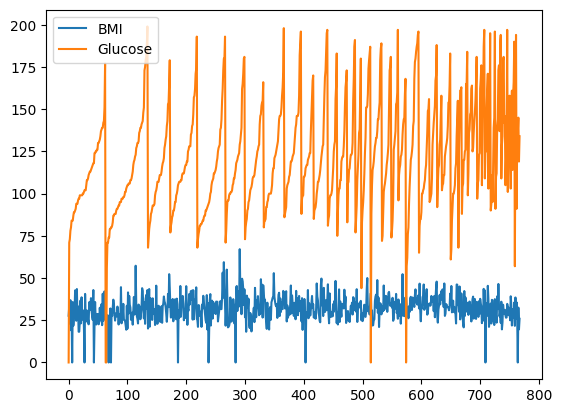

In [ ]:
df[['BMI', 'Glucose']].plot.line()

<Axes: >

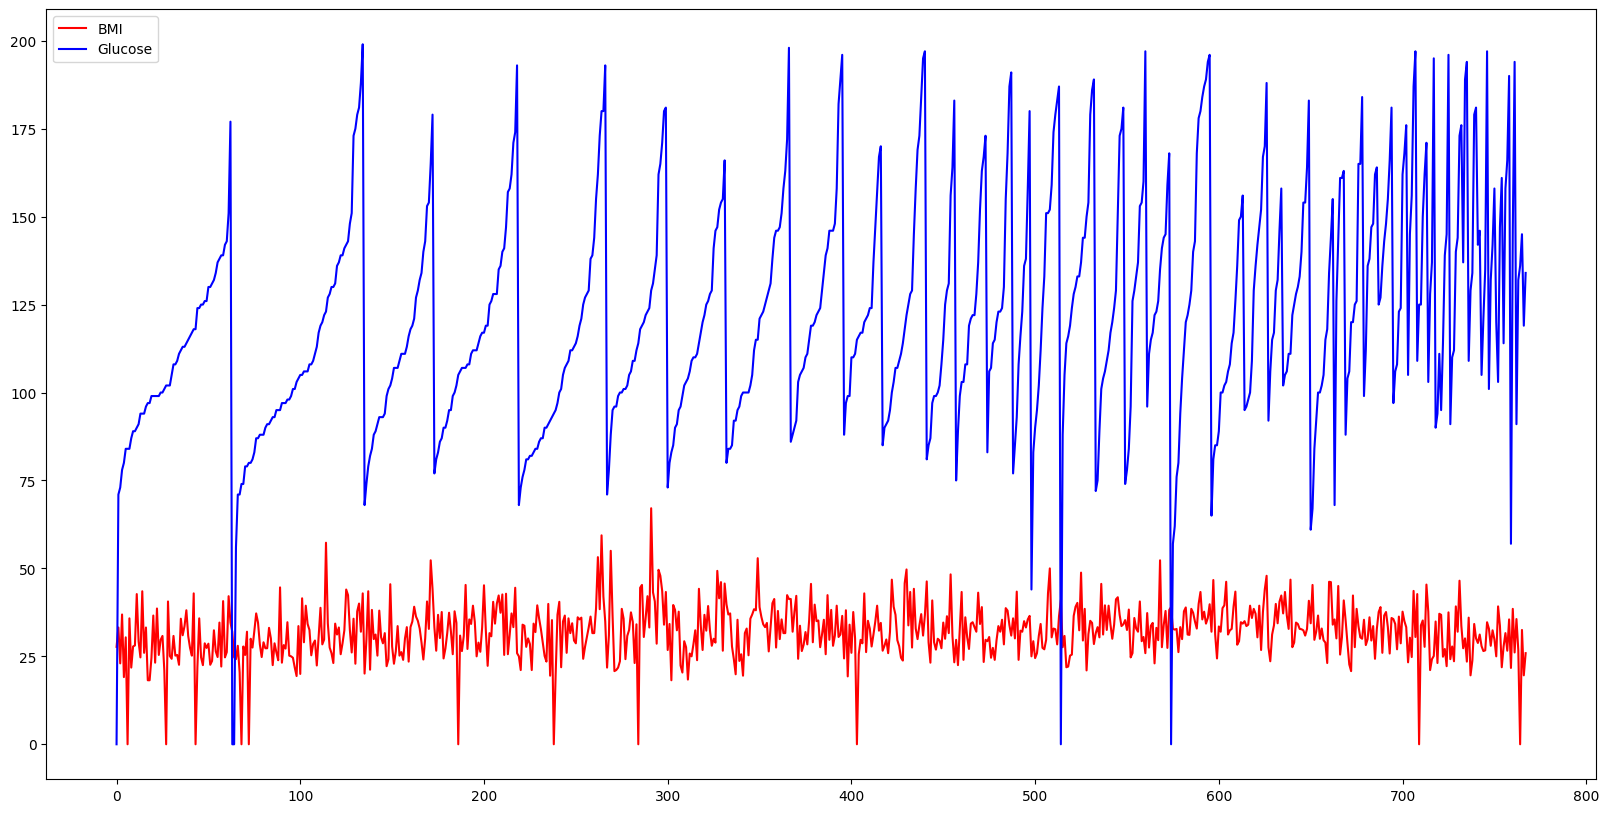

In [ ]:
df[['BMI', 'Glucose']].plot.line(figsize=(20, 10),
                                 color={"BMI": "red", "Glucose": "blue"})

All the columns of df can also be plotted on different scales and axes by using the subplots argument.

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >], dtype=object)

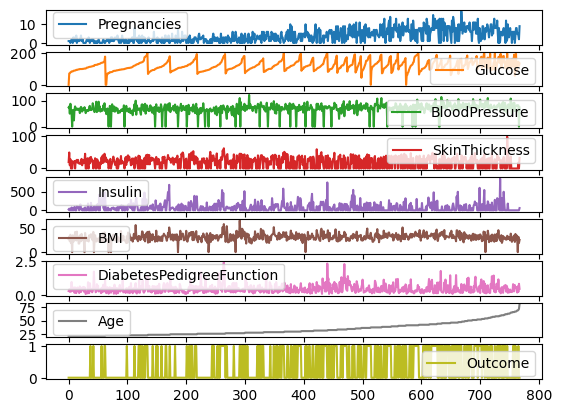

In [ ]:
df.plot.line(subplots=True)

**Bar plots in pandas**

For discrete columns, you can use a bar plot over the category counts to visualize their distribution. The variable Outcome with binary values is visualized below.

<Axes: xlabel='Outcome'>

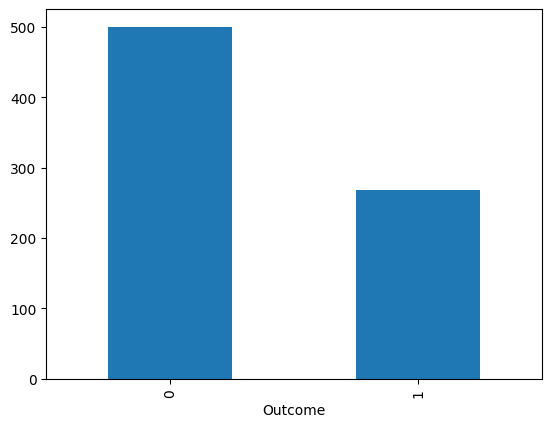

In [ ]:
df['Outcome'].value_counts().plot.bar()

**Box plots in pandas**

The quartile distribution of continuous variables can be visualized using a boxplot. The code below lets you create a boxplot with pandas.

<Axes: title={'center': 'BMI'}, xlabel='Outcome'>

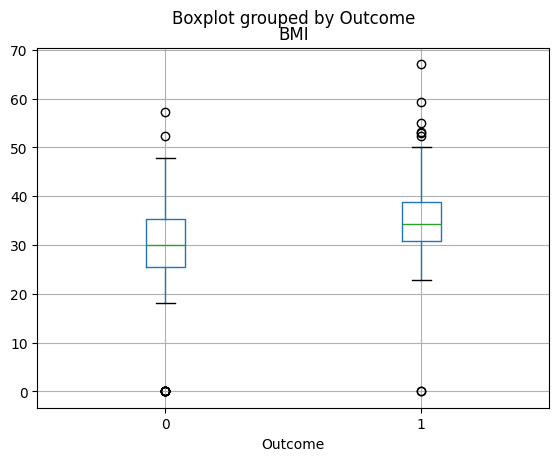

In [ ]:
df.boxplot(column=['BMI'], by='Outcome')